# Analysis of Global Tech Layoffs (2020-2024)
**Course:** MSDS670 - Data Visualization  
**Author:** Yassine Alami  
**Objective:** This notebook conducts an exploratory data analysis of the post-pandemic economic contraction within the technology sector. Utilizing the stateless object-oriented interface in Matplotlib, this project explores temporal volatility, categorical industry impacts, and the correlation between corporate funding stages and workforce reduction severity.
**Data Source:** https://www.kaggle.com/datasets/ulrikeherold/tech-layoffs-2020-2024

# Ingestion and Cleaning

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# 1. Data Ingestion
try:
    df = pd.read_csv('Tech_layoffs.csv')
    print("Dataset successfully loaded.")
except FileNotFoundError:
    print("Error: Please upload 'Tech_layoffs.csv' to the Colab environment.")

# 2. Data Cleaning and Preparation
df['Date_layoffs'] = pd.to_datetime(df['Date_layoffs'])

df['YearMonth'] = df['Date_layoffs'].dt.to_period('M')

df_clean = df.dropna(subset=['Laid_Off', 'Industry', 'Stage']).copy()

# 3. Validation
df_clean.head()

Dataset successfully loaded.


,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude,YearMonth
0,1,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766,2020-03
1,2,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766,2020-03
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329,2020-03
3,4,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700,2020-03
4,5,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,591.0,461.0,Travel,Series C,79.0,2020,39.739236,-104.984862,2020-03


# Visualization 1: The Temporal Line Plot

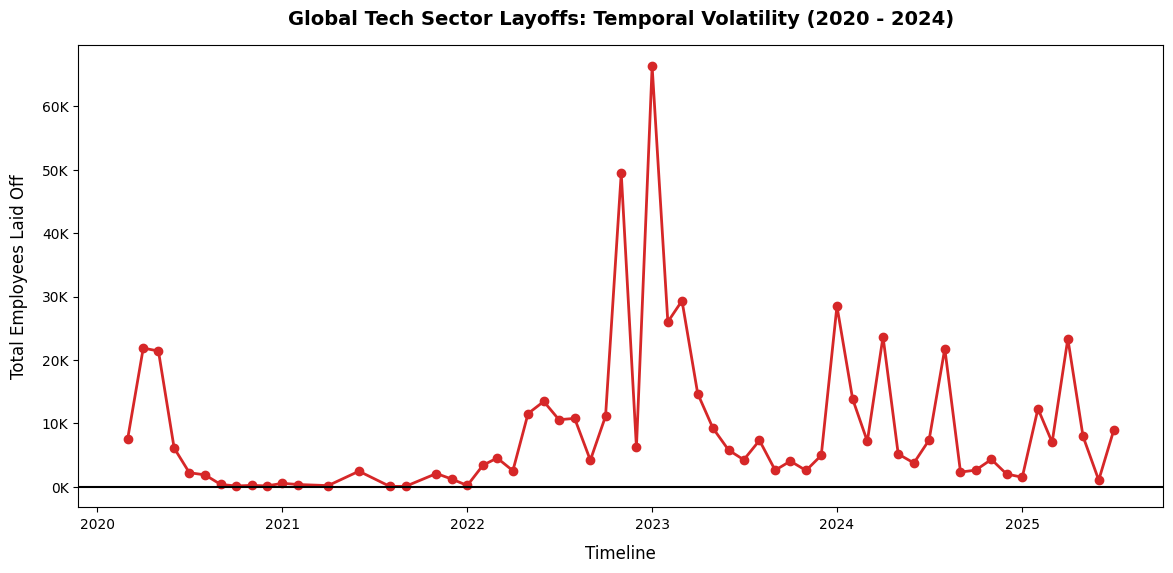

In [2]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# 1. Aggregate the Data
monthly_layoffs = df_clean.groupby('YearMonth')['Laid_Off'].sum().reset_index()

monthly_layoffs['YearMonth'] = monthly_layoffs['YearMonth'].dt.to_timestamp()

# 2. Initialize the Figure and Axes
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the time series line chart
ax.plot(monthly_layoffs['YearMonth'], monthly_layoffs['Laid_Off'], color='tab:red', linewidth=2, marker='o')

# Customize the chart aesthetics
ax.set_title('Global Tech Sector Layoffs: Temporal Volatility (2020 - 2024)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Timeline', fontsize=12, labelpad=10)
ax.set_ylabel('Total Employees Laid Off', fontsize=12, labelpad=10)

# 3. Formatting Rules
# Format the Y-axis to show thousands
formatter = FuncFormatter(lambda x, pos: f'{x*1e-3:,.0f}K')
ax.yaxis.set_major_formatter(formatter)

# Clean up the X-axis
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Add a solid baseline at Y=0
ax.axhline(0, color='black', linewidth=1.5, linestyle='-')

# Remove gridlines
ax.grid(False)

# 4. Export
fig.savefig('temporal_tech_layoffs.png', dpi=300, bbox_inches='tight', transparent=True)

# Display the final plot
plt.show()

# Visualization 2: Horizontal Bar Chart

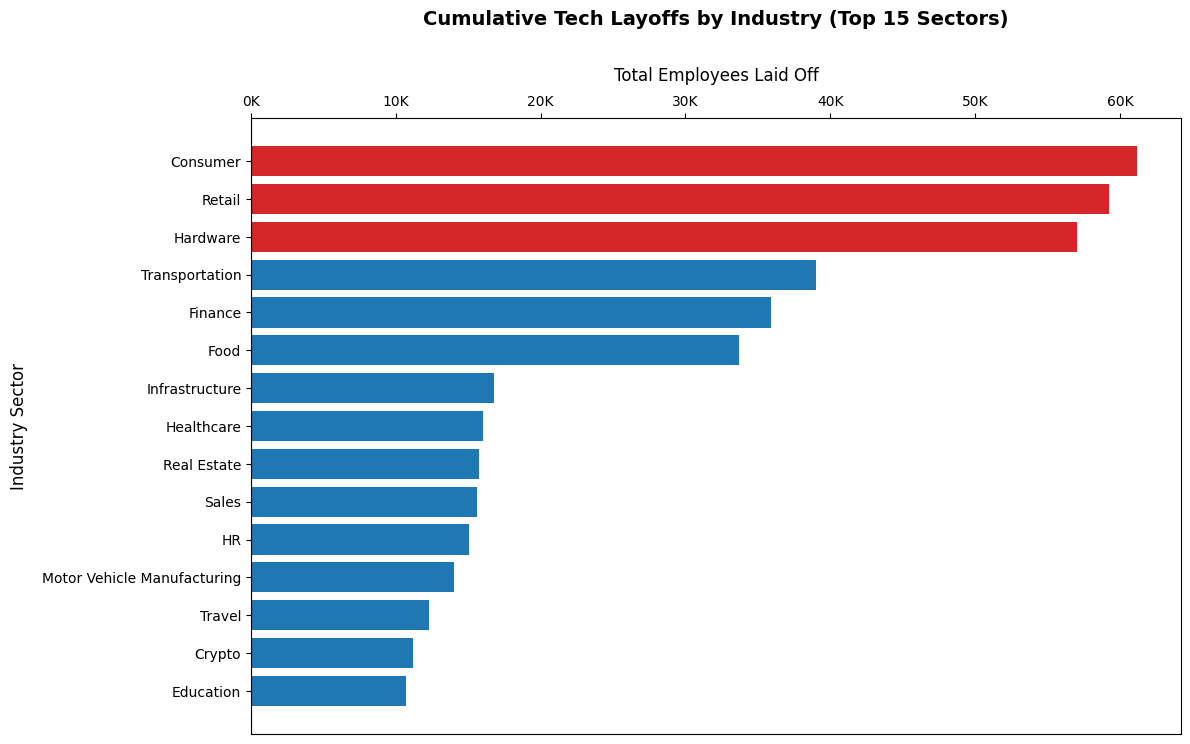

In [4]:
# 1. Categorical Data Engineering
# Filter out the 'Other' category
df_filtered = df_clean[df_clean['Industry'] != 'Other'].copy()

# Group by Industry, sum the layoffs, sort ascending, and isolate the top 15
industry_layoffs = df_filtered.groupby('Industry')['Laid_Off'].sum().sort_values().tail(15)

# Create a conditional color list
colors = ['tab:red' if i >= len(industry_layoffs) - 3 else 'tab:blue' for i in range(len(industry_layoffs))]

# 2. Initialize the Figure and Axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the sorted horizontal bar chart with conditional colors
bars = ax.barh(industry_layoffs.index, industry_layoffs.values, color=colors)

# Customize the chart aesthetics
ax.set_title('Cumulative Tech Layoffs by Industry (Top 15 Sectors)', fontsize=14, fontweight='bold', pad=30)
ax.set_xlabel('Total Employees Laid Off', fontsize=12, labelpad=10)
ax.set_ylabel('Industry Sector', fontsize=12, labelpad=10)

# Add a vertical zero-line anchor
ax.axvline(0, color='black', linewidth=1.5, linestyle='-')

# 3. Formatting
# Move the X-axis to the top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Format the X-axis to show thousands (e.g., 60000 -> 60K)
formatter = FuncFormatter(lambda x, pos: f'{x*1e-3:,.0f}K')
ax.xaxis.set_major_formatter(formatter)

# Remove gridlines
ax.grid(False)

# 4. Export
fig.savefig('categorical_layoffs.png', dpi=300, bbox_inches='tight', transparent=True)

# Display the final plot
plt.show()

# Visualization 3: Horizontal Box Plots

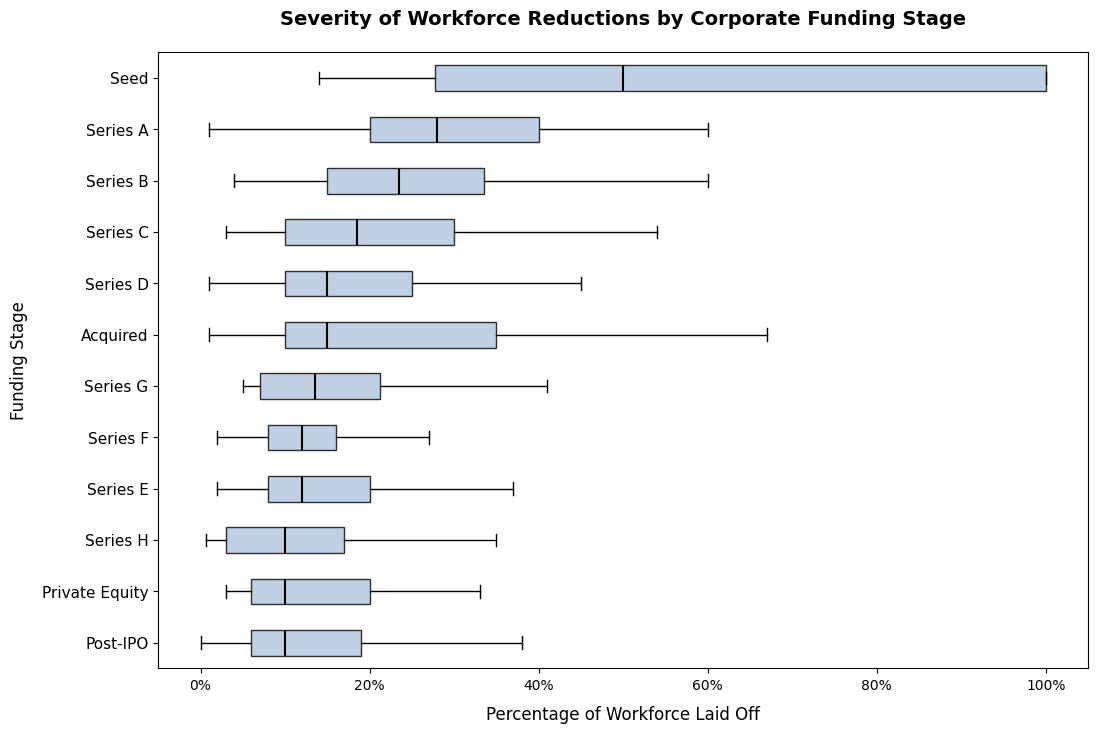

In [6]:
# 1. Distribution Engineering
# Isolate records with valid Percentage and Stage data
df_stage = df_clean.dropna(subset=['Percentage', 'Stage']).copy()

df_stage = df_stage[~df_stage['Stage'].astype(str).str.contains('Unknown', case=False, na=False)]

# Clean Y-axis
stage_counts = df_stage['Stage'].value_counts()
valid_stages = stage_counts[stage_counts > 10].index
df_box = df_stage[df_stage['Stage'].isin(valid_stages)].copy()

# Calculate the median percentage for each stage and sort them
median_percentages = df_box.groupby('Stage')['Percentage'].median().sort_values()
sorted_stages = median_percentages.index.tolist()

# Group data into a list of arrays for Matplotlib's boxplot function
percentage_by_stage = [df_box[df_box['Stage'] == stage]['Percentage'].values for stage in sorted_stages]

# 2. Initialize the Figure and Axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the horizontal box plots
bplot = ax.boxplot(percentage_by_stage,
                   vert=False,
                   patch_artist=True,
                   showfliers=False,
                   medianprops=dict(color='black', linewidth=1.5))

for patch in bplot['boxes']:
    patch.set_facecolor('lightsteelblue')
    patch.set_alpha(0.8)

# Customize the chart aesthetics
ax.set_yticklabels(sorted_stages, fontsize=11)
ax.set_title('Severity of Workforce Reductions by Corporate Funding Stage', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Percentage of Workforce Laid Off', fontsize=12, labelpad=10)
ax.set_ylabel('Funding Stage', fontsize=12, labelpad=10)

# 3. Formatting
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x:.0f}%')
ax.xaxis.set_major_formatter(formatter)

# Remove gridlines
ax.grid(False)

# 4. Export
fig.savefig('funding_stage_boxplots_final.png', dpi=300, bbox_inches='tight', transparent=True)

plt.show()